# 📊 Data Collection & Preprocessing Pipeline

In this section, multiple datasets were collected, cleaned, and merged to build a unified dataset for the job recommendation system.

---

# 🌐 1. Data Collection

## 🔹 RemoteOK API Dataset
- Data was collected using the **RemoteOK API**.
- Job postings were extracted using `requests`.
- Each job included:
  - Job Title
  - Company
  - Location
  - Job Description
  - Tags (Skills)
  - URL

📌 A total of **~97 initial records** were retrieved and stored.

---

## 🔹 Kaggle Dataset
- A second dataset was loaded from Kaggle containing **~3900 job records**.
- Included structured job information such as:
  - Job Title
  - Company
  - Location
  - Job Description
  - Salary (later removed)
  - Industry details

---

# 🧹 2. Data Cleaning Process

## 🔹 Text Cleaning
The following preprocessing steps were applied to job descriptions:

- Converted all text to lowercase
- Removed HTML tags
- Removed special characters and numbers
- Standardized text format for NLP processing

---

## 🔹 Handling Missing Values
- Missing locations were filled with `"remote"`
- Missing company names were filled with `"unknown"`
- Missing tags were handled appropriately

---

## 🔹 Removing Duplicates
- Duplicate job entries were removed based on:
  - `job_title`
  - `company`

---

## 🔹 Column Standardization
- Renamed inconsistent column names across datasets
- Unified structure across all sources

---

# 🔗 3. Data Integration

## 🔹 Merging Datasets
- RemoteOK dataset and Kaggle dataset were combined using `concat`
- Final dataset size: **~3687 job records**

---

## 🔹 Final Cleaning Steps
- Standardized text formatting for:
  - job_title → lowercase
  - location → unified (remote handling applied)
  - job_description → cleaned & trimmed

- Removed unnecessary columns (e.g., salary, url in some cases)

---

# 🧠 4. Feature Engineering

## 🔹 Job Category Creation
Jobs were grouped into simplified categories:

- Data Scientist
- Data Engineer
- Data Analyst
- Other

📌 This helped in reducing complexity and improving model understanding.

---

## 🔹 Skill Extraction
- A custom keyword-based method was used to extract skills from job descriptions.
- Skills included:
  - Python, SQL, Machine Learning, Deep Learning
  - Data Analysis, Excel, AWS, Docker, NLP, etc.

📌 Result:
- Created a new `skills` feature representing key technical requirements per job.

---

## 🔹 Text Limitation
- Job descriptions were truncated to **first 1000 characters**
to ensure uniform input size for NLP models.

---

# 📊 Final Dataset Overview

- Total records: **~3685 jobs**
- Columns:
  - job_title
  - company
  - location
  - job_description
  - skills
  - job_category

---

# 🎯 Final Insight

This preprocessing pipeline transformed raw, noisy job data from multiple sources into a **clean, unified, and machine-learning-ready dataset**.

The final dataset is:
- Structured
- Cleaned
- Standardized
- Enriched with extracted features (skills & categories)

---

# 🚀 Importance for the Project

This stage was critical because:

- It ensured **high-quality input for all NLP models (RNN, LSTM, GRU, BERT)**
- Improved consistency across different data sources
- Enabled meaningful semantic matching between CVs and job descriptions

In [ ]:
import requests
import pandas as pd

url = "https://remoteok.com/api"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
data = response.json()


jobs = data[1:]

jobs_list = []

for job in jobs:
    jobs_list.append({
        "job_title": job.get("position"),
        "company": job.get("company"),
        "location": job.get("location"),
        "job_description": job.get("description"),
        "tags": job.get("tags"),
        "url": job.get("url")
    })

df = pd.DataFrame(jobs_list)


df = df.head(800)

df.to_csv("jobs.csv", index=False)

print("Done! Dataset saved as jobs.csv")

Done! Dataset saved as jobs.csv


In [ ]:
df = pd.DataFrame(jobs_list)

In [ ]:
print(len(df))

97


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df["job_description"] = df["job_description"].apply(clean_text)

df.dropna(inplace=True)

df.to_csv("jobs_cleaned.csv", index=False)

print("Cleaned data saved!")

Cleaned data saved!


In [ ]:
df

,job_title,company,location,job_description,tags,url
0,Social Media Growth Lead,Black &amp; White Zebra,,about the rolewere looking for a social media ...,"[growth, ceo, testing, test, manager, video, l...",https://remoteOK.com/remote-jobs/remote-social...
1,Data Conversion Developer,Grant Street Group,United States (Remote),grant street group is looking for data convers...,"[developer, technical, support, code, analyst,...",https://remoteOK.com/remote-jobs/remote-data-c...
2,Director of Supply Chain,STR,Remote,about the rolestr is seeking an experienced an...,"[director, technical, support, lead, operational]",https://remoteOK.com/remote-jobs/remote-direct...
3,Account Executive,BlastPoint,,about blastpointblastpoint is a bb data analyt...,"[growth, financial, analytics, executive]",https://remoteOK.com/remote-jobs/remote-accoun...
4,Clinical Vendor Activation Manager,Care Access,USA Remote,about care accesscare access is working to mak...,"[manager, mobile, health, non tech]",https://remoteOK.com/remote-jobs/remote-clinic...
...,...,...,...,...,...,...
92,Technical Account Manager,Clariti Cloud Inc.,,join our mission to provide governments with e...,"[manager, technical, cloud, lead]",https://remoteOK.com/remote-jobs/remote-techni...
93,Implementation Specialist,Submittable,"Remote, U.S.",at submittable we are transforming how organiz...,"[training, support, software, director, health...",https://remoteOK.com/remote-jobs/remote-implem...
94,Proposal Manager @Advizex,Advizex,,about advizexadvizex a myriad company brings t...,"[manager, strategy, management, content, opera...",https://remoteOK.com/remote-jobs/remote-propos...
95,B2B Marketing Manager,Montu UK,Germany,montu therapeutics is building its bb commerci...,"[manager, support, web, video, strategy, lead,...",https://remoteOK.com/remote-jobs/remote-b2b-ma...


In [ ]:
len(data)


98

In [ ]:
df.drop_duplicates(subset=["job_title", "job_description"], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        97 non-null     object
 1   company          97 non-null     object
 2   location         97 non-null     object
 3   job_description  97 non-null     object
 4   tags             97 non-null     object
 5   url              97 non-null     object
dtypes: object(6)
memory usage: 4.7+ KB


In [ ]:
df["tags"] = df["tags"].apply(lambda x: ", ".join(x) if isinstance(x, list) else "")

In [ ]:
import re

def clean(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df["job_description"] = df["job_description"].apply(clean)

In [ ]:
df.head()

,job_title,company,location,job_description,tags,url
0,Social Media Growth Lead,Black &amp; White Zebra,,about the rolewere looking for a social media ...,"growth, ceo, testing, test, manager, video, le...",https://remoteOK.com/remote-jobs/remote-social...
1,Data Conversion Developer,Grant Street Group,United States (Remote),grant street group is looking for data convers...,"developer, technical, support, code, analyst, ...",https://remoteOK.com/remote-jobs/remote-data-c...
2,Director of Supply Chain,STR,Remote,about the rolestr is seeking an experienced an...,"director, technical, support, lead, operational",https://remoteOK.com/remote-jobs/remote-direct...
3,Account Executive,BlastPoint,,about blastpointblastpoint is a bb data analyt...,"growth, financial, analytics, executive",https://remoteOK.com/remote-jobs/remote-accoun...
4,Clinical Vendor Activation Manager,Care Access,USA Remote,about care accesscare access is working to mak...,"manager, mobile, health, non tech",https://remoteOK.com/remote-jobs/remote-clinic...


In [ ]:
df["tags"] = df["tags"].str.lower()

In [ ]:
import re

def clean(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df["job_description"] = df["job_description"].apply(clean)

In [ ]:
df["location"].fillna("remote", inplace=True)
df["company"].fillna("unknown", inplace=True)

/tmp/ipykernel_13805/968007798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["location"].fillna("remote", inplace=True)
/tmp/ipykernel_13805/968007798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
df.drop_duplicates(subset=["job_title", "job_description"], inplace=True)

In [ ]:
df

,job_title,company,location,job_description,tags,url
0,Social Media Growth Lead,Black &amp; White Zebra,,about the rolewere looking for a social media ...,"growth, ceo, testing, test, manager, video, le...",https://remoteOK.com/remote-jobs/remote-social...
1,Data Conversion Developer,Grant Street Group,United States (Remote),grant street group is looking for data convers...,"developer, technical, support, code, analyst, ...",https://remoteOK.com/remote-jobs/remote-data-c...
2,Director of Supply Chain,STR,Remote,about the rolestr is seeking an experienced an...,"director, technical, support, lead, operational",https://remoteOK.com/remote-jobs/remote-direct...
3,Account Executive,BlastPoint,,about blastpointblastpoint is a bb data analyt...,"growth, financial, analytics, executive",https://remoteOK.com/remote-jobs/remote-accoun...
4,Clinical Vendor Activation Manager,Care Access,USA Remote,about care accesscare access is working to mak...,"manager, mobile, health, non tech",https://remoteOK.com/remote-jobs/remote-clinic...
...,...,...,...,...,...,...
92,Technical Account Manager,Clariti Cloud Inc.,,join our mission to provide governments with e...,"manager, technical, cloud, lead",https://remoteOK.com/remote-jobs/remote-techni...
93,Implementation Specialist,Submittable,"Remote, U.S.",at submittable we are transforming how organiz...,"training, support, software, director, health,...",https://remoteOK.com/remote-jobs/remote-implem...
94,Proposal Manager @Advizex,Advizex,,about advizexadvizex a myriad company brings t...,"manager, strategy, management, content, operat...",https://remoteOK.com/remote-jobs/remote-propos...
95,B2B Marketing Manager,Montu UK,Germany,montu therapeutics is building its bb commerci...,"manager, support, web, video, strategy, lead, ...",https://remoteOK.com/remote-jobs/remote-b2b-ma...


In [ ]:
df.to_csv("jobs_cleaned.csv", index=False)

In [ ]:
df=pd.read_csv("/content/jobs_cleaned.csv")

In [ ]:
df.head()

,job_title,company,location,job_description,tags,url
0,Social Media Growth Lead,Black &amp; White Zebra,NaN,about the rolewere looking for a social media ...,"growth, ceo, testing, test, manager, video, le...",https://remoteOK.com/remote-jobs/remote-social...
1,Data Conversion Developer,Grant Street Group,United States (Remote),grant street group is looking for data convers...,"developer, technical, support, code, analyst, ...",https://remoteOK.com/remote-jobs/remote-data-c...
2,Director of Supply Chain,STR,Remote,about the rolestr is seeking an experienced an...,"director, technical, support, lead, operational",https://remoteOK.com/remote-jobs/remote-direct...
3,Account Executive,BlastPoint,NaN,about blastpointblastpoint is a bb data analyt...,"growth, financial, analytics, executive",https://remoteOK.com/remote-jobs/remote-accoun...
4,Clinical Vendor Activation Manager,Care Access,USA Remote,about care accesscare access is working to mak...,"manager, mobile, health, non tech",https://remoteOK.com/remote-jobs/remote-clinic...


In [ ]:
df.shape

(97, 6)

In [ ]:
df_remoteok=df

In [ ]:
df_remoteok["location"].fillna("remote", inplace=True)

/tmp/ipykernel_13805/32535895.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_remoteok["location"].fillna("remote", inplace=True)


In [ ]:
df_remoteok["tags"].fillna("unknown", inplace=True)

/tmp/ipykernel_13805/1349120133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_remoteok["tags"].fillna("unknown", inplace=True)


In [ ]:
import re

def clean(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df_remoteok["job_description"] = df_remoteok["job_description"].apply(clean)

In [ ]:
df_remoteok.rename(columns={"tags": "skills"}, inplace=True)

In [ ]:
df_remoteok.drop(columns=["url"], inplace=True)

In [ ]:
df_remoteok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        97 non-null     object
 1   company          97 non-null     object
 2   location         97 non-null     object
 3   job_description  97 non-null     object
 4   skills           97 non-null     object
dtypes: object(5)
memory usage: 3.9+ KB


In [ ]:
df_remoteok.head()

,job_title,company,location,job_description,skills
0,Social Media Growth Lead,Black &amp; White Zebra,remote,about the rolewere looking for a social media ...,"growth, ceo, testing, test, manager, video, le..."
1,Data Conversion Developer,Grant Street Group,United States (Remote),grant street group is looking for data convers...,"developer, technical, support, code, analyst, ..."
2,Director of Supply Chain,STR,Remote,about the rolestr is seeking an experienced an...,"director, technical, support, lead, operational"
3,Account Executive,BlastPoint,remote,about blastpointblastpoint is a bb data analyt...,"growth, financial, analytics, executive"
4,Clinical Vendor Activation Manager,Care Access,USA Remote,about care accesscare access is working to mak...,"manager, mobile, health, non tech"


# kaggle

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df_kaggle=pd.read_csv('/content/DataScientist.csv')

In [ ]:
df_kaggle

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,Hopper\n3.5,"New York, NY","Montreal, Canada",501 to 1000 employees,2007,Company - Private,Travel Agencies,Travel & Tourism,Unknown / Non-Applicable,-1,-1
1,1,1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,Noom US\n4.5,"New York, NY","New York, NY",1001 to 5000 employees,2008,Company - Private,"Health, Beauty, & Fitness",Consumer Services,Unknown / Non-Applicable,-1,-1
2,2,2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,-1.0,Decode_M,"New York, NY","New York, NY",1 to 50 employees,-1,Unknown,-1,-1,Unknown / Non-Applicable,-1,True
3,3,3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,Sapphire Digital\n3.4,"Lyndhurst, NJ","Lyndhurst, NJ",201 to 500 employees,2019,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,"Zocdoc, Healthgrades",-1
4,4,4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,United Entertainment Group\n3.4,"New York, NY","New York, NY",51 to 200 employees,2007,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"BBDO, Grey Group, Droga5",-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3904,3904,4375,AWS Data Engineer,$55K-$112K (Glassdoor est.),About Us\n\nTachyon Technologies is a Digital ...,4.4,Tachyon Technologies\n4.4,"Dublin, OH","Irving, TX",201 to 500 employees,2011,Company - Private,IT Services,Information Technology,$10 to $25 million (USD),-1,-1
3905,3905,4376,Data Analyst â Junior,$55K-$112K (Glassdoor est.),"Job description\nInterpret data, analyze resul...",5.0,"Staffigo Technical Services, LLC\n5.0","Columbus, OH","Woodridge, IL",51 to 200 employees,2008,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
3906,3906,4377,Security Analytics Data Engineer,$55K-$112K (Glassdoor est.),Job DescriptionThe Security Analytics Data Eng...,3.8,"PDS Tech, Inc.\n3.8","Dublin, OH","Irving, TX",5001 to 10000 employees,1977,Company - Private,Staffing & Outsourcing,Business Services,$100 to $500 million (USD),-1,-1
3907,3907,4378,Security Analytics Data Engineer,$55K-$112K (Glassdoor est.),The Security Analytics Data Engineer will inte...,4.0,Data Resource Technologies\n4.0,"Dublin, OH","Omaha, NE",1 to 50 employees,-1,Company - Private,Accounting,Accounting & Legal,Less than $1 million (USD),-1,-1


In [ ]:
df_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3909 non-null   int64  
 1   index              3909 non-null   int64  
 2   Job Title          3909 non-null   object 
 3   Salary Estimate    3909 non-null   object 
 4   Job Description    3909 non-null   object 
 5   Rating             3909 non-null   float64
 6   Company Name       3909 non-null   object 
 7   Location           3909 non-null   object 
 8   Headquarters       3909 non-null   object 
 9   Size               3909 non-null   object 
 10  Founded            3909 non-null   int64  
 11  Type of ownership  3909 non-null   object 
 12  Industry           3909 non-null   object 
 13  Sector             3909 non-null   object 
 14  Revenue            3909 non-null   object 
 15  Competitors        3909 non-null   object 
 16  Easy Apply         3909 

In [ ]:
df_kaggle.drop(columns=[
    "Unnamed: 0",
    "index",
    "Competitors",
    "Easy Apply"
], inplace=True)

In [ ]:
df_kaggle.rename(columns={
    "Job Title": "job_title",
    "Company Name": "company",
    "Location": "location",
    "Job Description": "job_description",
    "Industry": "industry",
    "Type of ownership": "ownership",
    "Size": "company_size",
    "Salary Estimate": "salary"
}, inplace=True)

In [ ]:
import re
import numpy as np

def clean_salary(s):
    if not isinstance(s, str):
        return np.nan

    s = s.lower()
    s = re.sub(r'[^\d\-]', '', s)

    if "-" in s:
        parts = s.split("-")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan
    else:
        try:
            return float(s)
        except:
            return np.nan

df_kaggle["salary"] = df_kaggle["salary"].apply(clean_salary)
df_kaggle["salary"].fillna(df_kaggle["salary"].mean(), inplace=True)

/tmp/ipykernel_13805/3918729390.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_kaggle["salary"].fillna(df_kaggle["salary"].mean(), inplace=True)


In [ ]:
df_kaggle["skills"] = df_kaggle["job_description"]

In [ ]:
df_kaggle["job_description"] = df_kaggle["job_description"].str.lower()

In [ ]:
df_kaggle = df_kaggle[[
    "job_title",
    "company",
    "location",
    "job_description",
    "skills",
    "salary"
]]

In [ ]:
df_kaggle.head()

,job_title,company,location,job_description,skills,salary
0,Senior Data Scientist,Hopper\n3.5,"New York, NY","about hopper\n\nat hopper, we’re on a mission ...","ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",146.0
1,"Data Scientist, Product Analytics",Noom US\n4.5,"New York, NY","at noom, we use scientifically proven methods ...","At Noom, we use scientifically proven methods ...",146.0
2,Data Science Manager,Decode_M,"New York, NY",decode_m\n\nhttps://www.decode-m.com/\n\ndata ...,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,146.0
3,Data Analyst,Sapphire Digital\n3.4,"Lyndhurst, NJ",sapphire digital seeks a dynamic and driven mi...,Sapphire Digital seeks a dynamic and driven mi...,146.0
4,"Director, Data Science",United Entertainment Group\n3.4,"New York, NY","director, data science - (200537)\ndescription...","Director, Data Science - (200537)\nDescription...",146.0


In [ ]:
df_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3909 entries, 0 to 3908
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        3909 non-null   object 
 1   company          3909 non-null   object 
 2   location         3909 non-null   object 
 3   job_description  3909 non-null   object 
 4   skills           3909 non-null   object 
 5   salary           3909 non-null   float64
dtypes: float64(1), object(5)
memory usage: 183.4+ KB


In [ ]:
df_kaggle.drop(columns=["salary"], inplace=True)

/tmp/ipykernel_13805/880699540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kaggle.drop(columns=["salary"], inplace=True)


In [ ]:
df_final = pd.concat([df_kaggle, df_remoteok], ignore_index=True)

df_final.drop_duplicates(
    subset=["job_title", "company"],  # مش description!
    inplace=True
)

In [ ]:
df_final.reset_index(drop=True, inplace=True)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        3687 non-null   object
 1   company          3687 non-null   object
 2   location         3687 non-null   object
 3   job_description  3687 non-null   object
 4   skills           3687 non-null   object
dtypes: object(5)
memory usage: 144.2+ KB


In [ ]:
df_final["location"] = df_final["location"].str.lower()

df_final["location"] = df_final["location"].apply(
    lambda x: "remote" if "remote" in x else x
)

In [ ]:
df_final["job_description"] = df_final["job_description"].str.replace("&amp;", "and")

In [ ]:
df_final["skills"] = df_final["skills"].str.lower()

In [ ]:
df_final["job_title"].value_counts().head(10)

,count
job_title,
Data Scientist,252
Data Engineer,237
Data Analyst,215
Senior Data Scientist,82
Senior Data Analyst,45
Machine Learning Engineer,43
Business Intelligence Analyst,38
Senior Data Engineer,37
Big Data Engineer,36


In [ ]:
df_final["job_title"] = df_final["job_title"].str.lower()

In [ ]:
df_final.sample(10)

,job_title,company,location,job_description,skills
897,data sceintist,Antuit\n4.0,"chicago, il",job description\nthe role\n\nantuit is looking...,job description\nthe role\n\nantuit is looking...
2093,aquatic scientist,Wood\n3.4,"san diego, ca",wood environment & infrastructure solutions is...,wood environment & infrastructure solutions is...
3081,data science engineer,OneModel,"austin, tx","data science engineerone model, the leading wo...","data science engineerone model, the leading wo..."
3640,senior site reliability engineer ai infrastruc...,Andromeda Cluster,san francisco,senior site reliability engineer ai infrastru...,"design, training, technical, software, code, m..."
2288,senior data engineer,Humana\n3.6,"san diego, ca",description\n\nthe senior software engineer co...,description\n\nthe senior software engineer co...
529,data engineer,Trovetechs Inc,"universal city, ca",greetings from trovetechs!!!\n\nâ\n\nwe have a...,greetings from trovetechs!!!\n\nâ\n\nwe have a...
1061,environmental data analyst - disaster recovery,ICF\n3.5,"houston, tx",are you interested in helping texas create com...,are you interested in helping texas create com...
3636,senior full stack engineer,Paperpile,remote,we use react and typescript across all our pro...,"senior, backend, front end"
76,data scientist,Interactive Brokers\n2.9,"new york, ny",data scientist join the interactive brokers te...,data scientist join the interactive brokers te...
382,scientist i,BioPhase Solutions\n4.9,"los angeles, ca",job description\nbiophase solutions specialize...,job description\nbiophase solutions specialize...


In [ ]:
def simplify_title(title):
    if "data scientist" in title:
        return "data scientist"
    elif "data engineer" in title:
        return "data engineer"
    elif "analyst" in title:
        return "data analyst"
    else:
        return "other"

df_final["job_category"] = df_final["job_title"].apply(simplify_title)

In [ ]:
df_final

,job_title,company,location,job_description,skills,job_category
0,senior data scientist,Hopper\n3.5,"new york, ny","about hopper\n\nat hopper, we’re on a mission ...","about hopper\n\nat hopper, we’re on a mission ...",data scientist
1,"data scientist, product analytics",Noom US\n4.5,"new york, ny","at noom, we use scientifically proven methods ...","at noom, we use scientifically proven methods ...",data scientist
2,data science manager,Decode_M,"new york, ny",decode_m\n\nhttps://www.decode-m.com/\n\ndata ...,decode_m\n\nhttps://www.decode-m.com/\n\ndata ...,other
3,data analyst,Sapphire Digital\n3.4,"lyndhurst, nj",sapphire digital seeks a dynamic and driven mi...,sapphire digital seeks a dynamic and driven mi...,data analyst
4,"director, data science",United Entertainment Group\n3.4,"new york, ny","director, data science - (200537)\ndescription...","director, data science - (200537)\ndescription...",other
...,...,...,...,...,...,...
3682,technical account manager,Clariti Cloud Inc.,remote,join our mission to provide governments with e...,"manager, technical, cloud, lead",other
3683,implementation specialist,Submittable,remote,at submittable we are transforming how organiz...,"training, support, software, director, health,...",other
3684,proposal manager @advizex,Advizex,remote,about advizexadvizex a myriad company brings t...,"manager, strategy, management, content, operat...",other
3685,b2b marketing manager,Montu UK,germany,montu therapeutics is building its bb commerci...,"manager, support, web, video, strategy, lead, ...",other


In [ ]:
df_final.duplicated(subset=["job_title", "company"]).sum()

np.int64(2)

In [ ]:
df_final.drop_duplicates(subset=["job_title", "company"], inplace=True)

In [ ]:
(df_final["job_description"].str.strip() == "").sum()

np.int64(0)

In [ ]:
df_final["job_description"].apply(len).describe()

,job_description
count,3687.000000
mean,3506.208842
std,1973.609054
min,42.000000
25%,2076.000000
50%,3263.000000
75%,4593.500000
max,19895.000000


In [ ]:
df_final["job_description"] = df_final["job_description"].apply(lambda x: x[:1000])

In [ ]:
df_final["job_description"].apply(len).describe()

,job_description
count,3685.000000
mean,975.182632
std,112.054453
min,42.000000
25%,1000.000000
50%,1000.000000
75%,1000.000000
max,1000.000000


In [ ]:
df_final["skills"].head()

,skills
0,"about hopper\n\nat hopper, we’re on a mission ..."
1,"at noom, we use scientifically proven methods ..."
2,decode_m\n\nhttps://www.decode-m.com/\n\ndata ...
3,sapphire digital seeks a dynamic and driven mi...
4,"director, data science - (200537)\ndescription..."


In [ ]:
def extract_skills(text):
    keywords = [
        "python", "sql", "machine learning", "deep learning",
        "data analysis", "excel", "tensorflow", "pandas",
        "nlp", "statistics", "aws", "docker"
    ]

    text = text.lower()
    found = [k for k in keywords if k in text]

    return ", ".join(found) if found else "unknown"

df_final["skills"] = df_final["job_description"].apply(extract_skills)

In [ ]:
df_final["skills"]

,skills
0,machine learning
1,"machine learning, data analysis"
2,"machine learning, excel, statistics"
3,unknown
4,machine learning
...,...
3682,unknown
3683,unknown
3684,unknown
3685,unknown


In [ ]:
df_final["skills"].value_counts().head()

,count
skills,
unknown,2060
machine learning,264
excel,180
data analysis,147
sql,141


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Vectorize text
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_tfidf = vectorizer.fit_transform(df_final["job_description"])

feature_names = vectorizer.get_feature_names_out()

# 2. استخراج skills لكل job
def extract_keywords(row, top_n=5):
    row_array = row.toarray()[0]
    top_indices = np.argsort(row_array)[-top_n:]
    return ", ".join([feature_names[i] for i in top_indices if row_array[i] > 0])

df_final["skills"] = [
    extract_keywords(row)
    for row in X_tfidf
]

In [ ]:
df_final["skills"].value_counts()

,count
skills,
"students, tutor, varsity, tutoring, tutors",21
"financial, ways, creates, payments, paypal",15
"community, world, ways, facebook, people",10
"world, education, offers, philadelphia, university",8
"run, deployment, behavior, powerful, information",7
...,...
"platform, public, data, strategy, microsoft",1
"analyst, az, global, phoenix, digital",1
"customer, individual, review, sql, data",1


In [ ]:
stop_words = set(["run", "world", "people", "ways", "information"])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    ngram_range=(1,2)  # مهم جدًا 🔥
)

In [ ]:
skill_bank = [
    "python", "sql", "machine learning", "deep learning",
    "data analysis", "excel", "aws", "docker", "nlp",
    "statistics", "r", "spark"
]

In [ ]:
def extract_skills(text):
    text = text.lower()
    found = [s for s in skill_bank if s in text]
    return ", ".join(found) if found else "other"

In [ ]:
df_final["skills"].value_counts()

,count
skills,
"students, tutor, varsity, tutoring, tutors",21
"financial, ways, creates, payments, paypal",15
"community, world, ways, facebook, people",10
"world, education, offers, philadelphia, university",8
"run, deployment, behavior, powerful, information",7
...,...
"platform, public, data, strategy, microsoft",1
"analyst, az, global, phoenix, digital",1
"customer, individual, review, sql, data",1


In [ ]:
df_final.to_csv("final_jobs_dataset.csv", index=False)

# ____________________________________________________________________________

# ((((((((((((((( **CV** ))))))))))))))))

# _____________________________________________________________________________________________________

# 📄 CV Data Collection & Preprocessing Pipeline

In this section, a resumes dataset was collected and processed to prepare it for the job recommendation system. The goal was to convert raw resume data into a clean, structured, and machine-learning-ready format.

---

# 🌐 1. Data Loading

- The dataset was loaded from a **JSONL file containing 3500 resumes**.
- Each resume included structured and unstructured information such as:
  - Resume ID
  - Category (Job Role)
  - Personal Information (Name, Email, Phone)
  - Location
  - Summary
  - Skills
  - Experience
  - Education
  - Full Text Description

📌 The dataset included both real and synthetic resumes.

---

# 🧹 2. Data Cleaning Process

## 🔹 Removing Sensitive / Unnecessary Columns
To focus only on useful features, the following columns were removed:
- Name
- Email
- Phone
- Summary
- Raw Text

📌 This step ensured privacy and reduced noise in the dataset.

---

## 🔹 Text Cleaning
A custom cleaning function was applied to standardize the text:

- Converted all text to lowercase
- Removed:
  - URLs
  - Numbers
  - Special characters
  - Extra spaces

📌 This helped normalize resume content for NLP processing.

---

## 🔹 Handling Missing / Mixed Data
- All columns were converted into string format
- Ensured consistency across all fields

---

# 🔗 3. Feature Engineering

## 🔹 Final Text Creation

A new feature was created:

> **final_text = clean_text + skills + experience**

📌 This combined:
- Resume description
- Skills
- Work experience

👉 Purpose:
> To create a rich representation of each candidate for semantic matching.

---

## 🔹 Skills Integration
- Skills were extracted and included in the final representation.
- Common skills included:
  - Python
  - SQL
  - Git
  - Linux
  - Machine Learning

---

## 🔹 Experience Enhancement
- Experience data was appended to improve context understanding.
- Helped models understand career level and background.

---

# 📊 4. Data Structure After Processing

After preprocessing, the dataset contained:

- ResumeID
- Category
- Location
- Skills
- Experience
- Education
- clean_text
- final_text

📌 Final dataset size:
> **3500 cleaned resumes**

---

# 🎯 Final Outcome

The CV dataset was transformed from raw, noisy resume data into a:

### ✔ Clean
### ✔ Structured
### ✔ Enriched
### ✔ NLP-ready dataset

---

# 🧠 Why This Step Was Important?

This preprocessing stage was critical because it:

- Removed personal and irrelevant information
- Unified resume formats
- Created meaningful textual representations
- Improved compatibility with NLP models (RNN, LSTM, GRU, BERT)

---

# 🚀 Final Insight

The CV pipeline ensured that each candidate is represented as a **single meaningful semantic text vector input**, which allows the recommendation system to accurately match candidates with suitable job opportunities.

---

# 🔥 One-Line Summary

> The CV dataset was cleaned, anonymized, and transformed into a unified semantic representation combining skills, experience, and description to enable accurate AI-based job matching.

In [ ]:
import pandas as pd

df_cv = pd.read_json('resumes_dataset (1).jsonl', lines=True)

C:\Users\Rahma mohamed\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
df_cv

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas
...,...,...,...,...,...,...,...,...,...,...,...,...
3495,SYNTH_3496,Technical Writer,Victor Green,victor.green@gmail.com,389.961.5738x5512,"Riveraville, DC",Dedicated Technical Writer with 9+ years of ex...,"Python, JavaScript, SQL, Git, Docker, AWS, Lin...",Principal Technical Writer at Apple (2022 - 20...,Bachelor of Science in Computer Science from S...,VICTOR GREEN\nEmail: victor.green@gmail.com | ...,Synthetic
3496,SYNTH_3497,Technical Writer,Jim Watson,jim.watson@hotmail.com,881.255.4260x9723,"West Kristin, NE",Dedicated Technical Writer with 7+ years of ex...,"Python, JavaScript, SQL, Git, Docker, AWS, Lin...",Technical Writer at Spotify (2021 - 2024): Imp...,Bachelor of Science in Information Systems fro...,Jim Watson\njim.watson@hotmail.com | 881.255.4...,Synthetic
3497,SYNTH_3498,Technical Writer,Katherine Kirby,katherine.kirby@yahoo.com,001-246-977-2051x71073,"West Patrickview, WV",Dedicated Technical Writer with 6+ years of ex...,"Python, JavaScript, SQL, Git, Docker, AWS, Lin...",Lead Technical Writer at GitHub (2021 - 2024):...,Bachelor of Engineering in Software Engineerin...,═══ Katherine Kirby ═══\n📧 katherine.kirby@yah...,Synthetic
3498,SYNTH_3499,Technical Writer,Denise Schmidt,denise.schmidt@hotmail.com,001-637-303-1754x38027,"Wesleymouth, VT",Dedicated Technical Writer with 6+ years of ex...,"Python, JavaScript, SQL, Git, Docker, AWS, Lin...",Senior Technical Writer at Meta (2022 - 2024):...,Master of Engineering in Software Engineering ...,DENISE SCHMIDT\nEmail: denise.schmidt@hotmail....,Synthetic


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_cv["clean_text"] = df_cv["Text"].apply(clean_text)

In [ ]:
df_cv["final_text"] = (
    df_cv["clean_text"] + " " +
    df_cv["Skills"].astype(str) + " " +
    df_cv["Experience"].astype(str)
)

In [ ]:
df_cv.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source,clean_text,final_text
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas,jared arthur maica java developer linkedincomi...,jared arthur maica java developer linkedincomi...
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,jessica claire resumesampleexamplecom montgome...,jessica claire resumesampleexamplecom montgome...
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas,jessica claire resumesampleexamplecom montgome...,jessica claire resumesampleexamplecom montgome...
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas,jessica claire montgomery st th floor xxx resu...,jessica claire montgomery st th floor xxx resu...


In [ ]:
df_cv.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ResumeID    3500 non-null   str  
 1   Category    3500 non-null   str  
 2   Name        3500 non-null   str  
 3   Email       3500 non-null   str  
 4   Phone       3500 non-null   str  
 5   Location    3500 non-null   str  
 6   Summary     3500 non-null   str  
 7   Skills      3500 non-null   str  
 8   Experience  3500 non-null   str  
 9   Education   3500 non-null   str  
 10  Text        3500 non-null   str  
 11  Source      3500 non-null   str  
 12  clean_text  3500 non-null   str  
 13  final_text  3500 non-null   str  
dtypes: str(14)
memory usage: 39.6 MB


In [ ]:
df_cv.drop(columns=["Name", "Email", "Phone"], inplace=True)

In [ ]:
df_cv.drop(columns=["Summary", "Text"], inplace=True)

In [ ]:
df_cv.to_csv("cv_cleaned.csv", index=False)

# (((((((( IMAGE ))))))))

# 🖼️ Image Dataset Preprocessing Summary

## 📥 Data Extraction
The image dataset was extracted from a compressed file (`graphs.zip`) and unpacked into the `graphs_dataset` directory for further processing.

---

## 🧹 Data Cleaning
File names were cleaned to fix issues such as:
- Duplicate extensions (.jpg.jpg)
- Inconsistent naming formats
- Organizing files into a structured directory

This ensured smooth loading and processing of images later.

---

## 🔍 Data Exploration
File names were analyzed to understand the dataset categories:

- bar
- pie
- graph
- flow
- diagram
- table
- growth

This step helped identify the structure of the dataset before labeling.

---

## 🏷️ Image Classification (Rule-based)
Images were automatically labeled using keyword-based mapping:

- data_visualization → (bar, pie, graph, growth)
- diagrams → (flow, diagram)
- tables → (table)

This transformed the dataset into a structured classification format.

---

## ⚖️ Dataset Balancing
The dataset was balanced to reduce class bias:

- data_visualization → 3000 images
- diagrams → 3000 images
- tables → 2067 images

---

## 📏 Image Preprocessing
All images were prepared for training by:

- Converting images to RGB format
- Resizing all images to 224×224
- Standardizing input dimensions
- Ensuring no corrupted images (Broken images = 0)

---

## 📊 Final Dataset Analysis
We verified:
- Correct class distribution
- Dataset readiness for training
- Consistent image dimensions

---

## 📦 Final Output
The processed dataset was saved as:

`image_dataset_clean.zip`

---

## 🎯 Conclusion
A complete image preprocessing pipeline was built including:

- Extraction
- Cleaning
- Labeling
- Balancing
- Preprocessing

✔ Final result: A fully prepared dataset ready for training deep learning (CNN) models without quality or distribution issues.

In [ ]:
import os
import shutil
from PIL import Image

In [ ]:
import shutil
import os


zip_path = "graphs.zip"


extract_path = "graphs_dataset"


os.makedirs(extract_path, exist_ok=True)


shutil.unpack_archive(zip_path, extract_path)

print("Extracted successfully")

Extracted successfully


In [ ]:
import os

print(os.listdir("graphs_dataset"))

['bar_chart_0006-006-Stolbchataja-diagramma.jpg.jpg', 'bar_chart_008.jpg.jpg', 'bar_chart_013d0eca-b83e-414c-a36e-2643be4afdf5.jpg', 'bar_chart_016f9769-c0d4-4d4a-8826-50769edf4344.jpg', 'bar_chart_0183d9dc691b8c66d60814b4a1c88037.jpg.jpg', 'bar_chart_01f69819-ac2a-4680-a610-61e2b05a6408.jpg', 'bar_chart_0275.png.jpg', 'bar_chart_02e01f97-f11d-4c3c-9270-bbfd987f642a.jpg', 'bar_chart_030d1ee9-7434-4cb2-8b01-315489cb290e.jpg', 'bar_chart_043e0759-0346-44ce-9d6f-f844b9b10c49.jpg', 'bar_chart_0699799181d3c30ae803260a34f6c3e0.png.jpg', 'bar_chart_07154450-b2cc-4eaf-904d-4f86dc0277d7.jpg', 'bar_chart_0784e50b-7de6-470d-9acb-ed0e9de4a68c.jpg', 'bar_chart_0826ef37-7391-4af9-9378-863cd713c795.jpg', 'bar_chart_0b2837a5-87d9-4d97-b63e-19a0187614d2.jpg', 'bar_chart_0b9f4daf-21b3-461f-b30a-ef03daa189a9.png.jpg', 'bar_chart_0BDD0B0D187D0B5D0BDD0B8D18FD0BCD0B8-D0B3D0BED0B4D0BED0B2-D0BFD180D0BED0B2D0B5D0B4D0B5D0BDD0B8D18F-D181D0BED180D0B5D0B2D0BDD0BED0B2D0B0D0BDD0B8D0B9.jpg.jpg', 'bar_chart_0cbc315a-d

In [ ]:
import os
import shutil

source = "graphs_dataset"
target = "clean_dataset/bar_chart"

os.makedirs(target, exist_ok=True)

for file in os.listdir(source):
    old_path = os.path.join(source, file)


    new_name = file.replace(".jpg.jpg", ".jpg")

    new_path = os.path.join(target, new_name)

    shutil.copy(old_path, new_path)

print("Done cleaning + moving images")

Done cleaning + moving images


In [ ]:
import os

files = os.listdir("graphs_dataset")


types = set([f.split("_")[0] for f in files])

print(types)

{'flow', 'bar', 'growth', 'pie', 'just', 'graph', 'table', 'diagram'}


In [ ]:
import os
import shutil

source_dir = "graphs_dataset"
target_dir = "image_dataset"

mapping = {
    "bar": "data_visualization",
    "pie": "data_visualization",
    "graph": "data_visualization",
    "growth": "data_visualization",

    "flow": "diagrams",
    "diagram": "diagrams",

    "table": "tables"
}

os.makedirs(target_dir, exist_ok=True)

for file in os.listdir(source_dir):

    file_lower = file.lower()

    label = None


    for key in mapping.keys():
        if key in file_lower:
            label = key
            break

    if label:
        new_class = mapping[label]

        class_folder = os.path.join(target_dir, new_class)
        os.makedirs(class_folder, exist_ok=True)

        src_path = os.path.join(source_dir, file)
        dst_path = os.path.join(class_folder, file)

        shutil.copy(src_path, dst_path)

print("Dataset cleaned and reorganized successfully!")

Dataset cleaned and reorganized successfully!


In [ ]:
import os

folder = "image_dataset"

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)
    count = len(os.listdir(class_path))
    print(class_name, ":", count, "images")

data_visualization : 6987 images
diagrams : 3708 images
tables : 2067 images


In [ ]:
import os
import random
import shutil

source = "image_dataset"
target = "balanced_dataset"

os.makedirs(target, exist_ok=True)

target_count = 3000

for class_name in os.listdir(source):

    class_path = os.path.join(source, class_name)
    images = os.listdir(class_path)


    if len(images) > target_count:
        images = random.sample(images, target_count)


    new_class_path = os.path.join(target, class_name)
    os.makedirs(new_class_path, exist_ok=True)

    for img in images:
        src = os.path.join(class_path, img)
        dst = os.path.join(new_class_path, img)
        shutil.copy(src, dst)

print("Balanced dataset created successfully!")

Balanced dataset created successfully!


In [ ]:
import os

folder = "balanced_dataset"

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)
    count = len(os.listdir(class_path))
    print(class_name, ":", count, "images")

data_visualization : 3000 images
diagrams : 3000 images
tables : 2067 images


In [ ]:
from PIL import Image
import os

folder = "balanced_dataset"

sizes = []

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)  # (width, height)
        except:
            pass

print("Total images:", len(sizes))
print("Example sizes:", sizes[:10])

Total images: 8067
Example sizes: [(960, 720), (960, 720), (1024, 767), (350, 271), (960, 720), (378, 283), (720, 540), (310, 232), (800, 600), (676, 685)]


In [ ]:
unique_sizes = set(sizes)
print("Unique image sizes:", unique_sizes)

Unique image sizes: {(433, 116), (630, 401), (315, 160), (828, 645), (535, 429), (368, 401), (976, 809), (672, 663), (905, 1014), (450, 470), (1600, 1167), (500, 327), (494, 741), (335, 259), (334, 151), (400, 325), (280, 180), (748, 285), (365, 138), (257, 196), (461, 600), (400, 361), (593, 496), (460, 232), (209, 241), (600, 800), (500, 304), (298, 169), (799, 600), (1008, 710), (693, 555), (248, 204), (1024, 574), (952, 1080), (1300, 1003), (250, 250), (627, 502), (117, 400), (271, 229), (283, 203), (800, 1067), (201, 250), (1568, 530), (221, 228), (793, 799), (367, 282), (186, 270), (1024, 1369), (692, 896), (503, 700), (1200, 628), (615, 416), (3495, 4189), (280, 170), (968, 507), (1188, 1593), (412, 289), (720, 405), (216, 234), (336, 150), (282, 179), (903, 526), (620, 354), (800, 550), (4962, 3509), (607, 384), (559, 344), (350, 350), (399, 126), (153, 330), (255, 198), (1034, 573), (197, 256), (854, 1280), (1024, 708), (662, 621), (213, 237), (651, 957), (1200, 870), (365, 19

In [ ]:
from PIL import Image
import os

folder = "balanced_dataset"
size = (224, 224)

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)


            img = img.convert("RGB")

            img = img.resize(size)
            img.save(img_path, "JPEG")

        except Exception as e:
            print("Error:", img_path, e)

In [ ]:
from PIL import Image
import os

folder = "balanced_dataset"

sizes = []

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            sizes.append(img.size)  # (width, height)
        except:
            pass

print("Total images:", len(sizes))
print("Example sizes:", sizes[:10])

Total images: 8067
Example sizes: [(224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224), (224, 224)]


In [ ]:
unique_sizes = set(sizes)
print("Unique image sizes:", unique_sizes)

Unique image sizes: {(224, 224)}


In [ ]:
from PIL import Image

broken = []

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            Image.open(img_path).verify()
        except:
            broken.append(img_path)

print("Broken images count:", len(broken))
print(broken[:10])

Broken images count: 0
[]


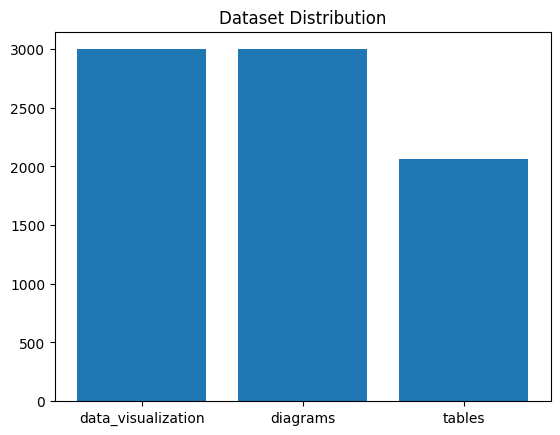

In [ ]:
import matplotlib.pyplot as plt

classes = []
counts = []

for class_name in os.listdir(folder):
    class_path = os.path.join(folder, class_name)

    classes.append(class_name)
    counts.append(len(os.listdir(class_path)))

plt.bar(classes, counts)
plt.title("Dataset Distribution")
plt.show()

In [ ]:
import shutil

shutil.make_archive("image_dataset_clean", 'zip', "balanced_dataset")

print("Dataset zipped successfully!")

Dataset zipped successfully!


In [ ]:
import os

folder = "balanced_dataset"

for c in os.listdir(folder):
    path = os.path.join(folder, c)
    print(c, ":", len(os.listdir(path)))

data_visualization : 3000
diagrams : 3000
tables : 2067
